# Predictive Analytics & Smart Insights for Garment Production

## Executive Summary


### Context
The garment industry is a labor-intensive sector where productivity directly impacts operational costs, staffing, and delivery timelines. This study replaces traditional, static human target-setting (`targeted_productivity`) with a **machine learning classification approach** to accurately predict daily team performance, identify key operational drivers, and provide a **simulation tool for data-driven decision-making**.

### Approach & Model Selection
Using daily manufacturing task data split into an **80/20 train-test ratio**, we evaluated multiple models (including Ridge, XGBoost, LGBM, and Extra Trees) using standardized preprocessing pipelines and **Stratified Cross-Validation** to prevent data leakage.<br>
- **Final Model: Random Forest Regressor** optimized via `RandomizedSearchCV`.<br>
- **Test Performance:** Achieved a **Quadratic Weighted Kappa (QWK) of 0.6485** and a **Mean Absolute Error (MAE) of 0.4833**.
- **Error Distribution**: Large misclassifications are extremely rare; average deviations are **under half a class (MAE < 0.5)**, with **zero absolute error in nearly 150 instances**.

### Key Insights & Benchmark Comparison
- **35.14% Lift Over Human Targets:** The ML model achieves **62.50% overall accuracy** compared to **46.25%** from traditional target setting. It also reduces prediction error (MAE) by **33.53% (0.4792 vs. 0.7208)**.<br>
- **Superior Balanced Classification:** The model drastically outperforms human targets in **Macro F1 (0.6113 vs. 0.3630, a 68.39% lift)** and **Weighted F1 (0.6233 vs. 0.3944, a 58.05% lift)**.<br>
- **Elimination of High-Productivity Blind Spots**: Traditional targets completely fail to identify top-performing shifts (**Class 4: 0% Precision/Recall**). The ML model effectively captures high-productivity instances with **71% Precision (0.58 F1-score)**.<br>
- **Key Operational Drivers (SHAP & Feature Importance)**: Financial `incentive` emerged as the single most critical driver of performance, followed by `smv` (Standard Minute Value), `no_of_workers`, and `over_time`. These variables exhibit complex, non-linear interactions across different shifts.<br>

### Industrial Implications
- **Correction of Systematic Target Overestimation**: Traditional targets over-promise intermediate output (Classes 2 & 3) while ignoring Class 4 capacity. The model realigns plant expectations with historical reality, **preventing supply chain bottlenecks**.<br>
- **Reduction of Planning Errors**: Minimizing 1- and 2-class misalignments prevents **costly over- or under-staffing** on the floor.<br>
- **Data-Driven "What-If" Simulations:** Plant managers can leverage the pipeline as a decision-support system to test changes in incentives, team sizing, and overtime **before allocating operational budget**.<br>

### Strategic Recommendations
- **Replace Static Goal-Setting:** Transition plant planning from traditional human targeting to the Random Forest predictive model to **eliminate high-productivity blind spots and stabilize scheduling**.<br>
- **Deploy Simulation Tools for Floor Managers**: Operationalize the predictive pipeline into a front-end simulation interface, allowing managers to **optimize actionable levers prior to shift start**.<br>
- **Restructure Incentive Alignment**: Prioritize financial incentives and team size recalibration as the primary levers for **driving high-productivity shifts (Class 4)**.

## Introduction

The garment industry is a highly labor-intensive industry with lots of manual processes. So, it is highly desirable among the decision makers in the garment industry to track, analyse, and predict the productivity performance of the working teams in their factories.  
The production of a garment company is a sequential process which includes a series of operations such as designing, sample confirmation, sourcing and merchandising, lay planning, market planning, spreading and cutting, sewing, washing, finishing and packaging. The whole production target and the performance of this industry highly rely on the performance of the employees.
To keep the production performance and achieve objectives, it is systematically monitored and analyzed. Most companies are still doing this process manually.
The prediction of productivity in working teams is highly desirable among decision-makers. Furthermore, understanding the causes of low performance would enable management to take steps to optimize production and costs.

**About the dataset:**  
This dataset tracks daily production performance across different factory lines. Each line is a mix of machines and workers set up specifically for a certain clothing style. We use this data to compare performance, calculate labor costs, and plan factory capacity.

**The Main Drivers:**
- SMV (Standard Minute Value): The "target time" allowed to finish a specific task. It changes depending on the garment's complexity, fabric, and design.
- WIP (Work in Progress): The number of unfinished items currently sitting in the production pipeline (cutting, sewing, or finishing). It's a great way to spot bottlenecks.
- Overtime: Any work done beyond the standard 8-hour shift. While it helps hit deadlines, too much of it can actually hurt productivity due to worker fatigue.
- Incentives: Extra pay given to workers for hitting or exceeding their targets. In this study, we focus only on "structured" financial incentives, as they are the primary tool for boosting output.


**The Goals:**
- Predict Actual Productivity: We build models to categorize how teams will actually perform.
- Find Hidden Patterns: We extract insights from the data to answer tough business questions.
- Provide a tool for decision makers to improve the predicted productivity.

### Library and data load

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.optimize import minimize

from sklearn.base import clone

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score, 
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    make_scorer,
    mean_absolute_error, 
    f1_score 
)
from sklearn.model_selection import StratifiedKFold, train_test_split, RandomizedSearchCV, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

import shap

import warnings
warnings.filterwarnings('ignore', message=".*'force_all_finite' was renamed to 'ensure_all_finite'.*")

In [2]:
# load dataset
df = pd.read_csv('../data/raw/garments_worker_productivity.csv')

In [3]:
# set plotting parameters
font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size' : 10}
axes = { 'titlesize' : 15,
         'labelsize' : 13}
figure = {'figsize':(10,4),
          'autolayout':True,
         'titlesize' : 25,
         'labelsize' : 13}

sns.set_palette("plasma") # colorblind-friendly
plt.rc('font', **font)
plt.rc('axes', **axes)
plt.rc('figure', **figure)

## EDA

### Data types

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   object 
 1   quarter                1197 non-null   object 
 2   department             1197 non-null   object 
 3   day                    1197 non-null   object 
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: f

Meaning of features:

date: Date in MM-DD-YYYY.  
day: Day of the week, represented as strings.  
quarter: A portion of the month. A month was divided into four/five quarters of seven days.  
department:	Associated department with the instance: sewing or finishing    
team_no: Associated team number with the instance.  
no_of_workers: Number of workers in each team.  
no_of_style_change:	Number of changes in the style of a particular product. Integer 0, 1 or 2.    
targeted_productivity: Targeted productivity set by the Authority for each team for each day.  
smv: Standard Minute Value, it is the allocated time for a task.  
wip: Work in progress. Includes the number of unfinished items for products.  
over_time: Represents the amount of overtime by each team in minutes (as the sum of all their members). Daily eight hours of working is counted as the normal working hour and beyond that is called overtime.  
incentive: Represents the amount of financial incentive (in BDT) that enables or motivates a particular course of action. Incentives help the employees directly through the form of higher pay for achieving the milestone or targeted performance, so it fluctuates with the change in performance level.  
idle_time: The amount of time during which the production was interrupted due to several reasons.  
idle_men: The number of workers who were idle due to production interruption.  
actual_productivity: The actual % of productivity that was delivered by the workers. It ranges from 0-1.  

### Data overview and cleaning

In [5]:
df.drop_duplicates(inplace=True)
df.head(20)

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382
5,1/1/2015,Quarter1,sweing,Thursday,7,0.80,25.90,984.0,6720,38,0.0,0,0,56.0,0.800125
6,1/1/2015,Quarter1,finishing,Thursday,2,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.755167
7,1/1/2015,Quarter1,sweing,Thursday,3,0.75,28.08,795.0,6900,45,0.0,0,0,57.5,0.753683
8,1/1/2015,Quarter1,sweing,Thursday,2,0.75,19.87,733.0,6000,34,0.0,0,0,55.0,0.753098
9,1/1/2015,Quarter1,sweing,Thursday,1,0.75,28.08,681.0,6900,45,0.0,0,0,57.5,0.750428


In [6]:
df.describe()

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,1197.000000,1197.000000,1197.000000,691.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000
mean,6.426901,0.729632,15.062172,1190.465991,4567.460317,38.210526,0.730159,0.369256,0.150376,34.609858,0.735091
std,3.463963,0.097891,10.943219,1837.455001,3348.823563,160.182643,12.709757,3.268987,0.427848,22.197687,0.174488
min,1.000000,0.070000,2.900000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.233705
25%,3.000000,0.700000,3.940000,774.500000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.650307
50%,6.000000,0.750000,15.260000,1039.000000,3960.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.773333
75%,9.000000,0.800000,24.260000,1252.500000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,0.850253
max,12.000000,0.800000,54.560000,23122.000000,25920.000000,3600.000000,300.000000,45.000000,2.000000,89.000000,1.120437


In [7]:
df['date'] = pd.to_datetime(df['date'])

In [8]:
print(df['date'].value_counts())
print(df['date'].nunique())

date
2015-03-11    24
2015-01-31    24
2015-01-11    23
2015-03-10    23
2015-01-12    23
2015-01-24    23
2015-01-08    22
2015-01-10    22
2015-01-07    22
2015-01-13    22
2015-01-05    22
2015-03-09    22
2015-03-08    22
2015-03-03    22
2015-01-22    22
2015-02-25    21
2015-02-26    21
2015-02-28    21
2015-01-03    21
2015-01-04    21
2015-01-28    21
2015-01-27    21
2015-03-04    21
2015-01-25    21
2015-01-17    21
2015-01-14    21
2015-01-06    21
2015-02-18    21
2015-01-29    20
2015-02-17    20
2015-03-02    20
2015-03-01    20
2015-02-22    20
2015-02-19    20
2015-03-05    19
2015-03-07    19
2015-02-24    19
2015-02-23    19
2015-01-01    19
2015-02-03    19
2015-02-15    19
2015-01-15    19
2015-01-18    19
2015-01-19    19
2015-01-21    19
2015-01-26    19
2015-02-01    19
2015-02-02    19
2015-02-04    19
2015-02-07    19
2015-02-08    19
2015-02-10    19
2015-02-11    19
2015-02-12    19
2015-02-05    18
2015-02-09    18
2015-02-16    18
2015-02-14    17
2015-01-2

Trim whitespace and replace the typo: "sweing" with "sewing"

In [9]:
df['department'] = df['department'].str.strip() #correct the labels
df['department'] = df['department'].replace('sweing', 'sewing')

Let's observe that the 'finishing' was not a daily task, in fact: in January just one team in one day worked in finishing

In [10]:
df['department'] = df['department'].str.strip() #correct the labels
df['department'].value_counts()

department
sewing       691
finishing    506
Name: count, dtype: int64

In [11]:
finishing_monthly = df[df['department'] == 'finishing'] \
    .groupby(pd.Grouper(key='date', freq='ME')) \
    .size() \
    .reset_index(name='finishing_count') #group the finishing by date and count

finishing_monthly

,date,finishing_count
0,2015-01-31,235
1,2015-02-28,174
2,2015-03-31,97


In [12]:
sewing_monthly = df[df['department'] == 'sewing'] \
    .groupby(pd.Grouper(key='date', freq='ME')) \
    .size() \
    .reset_index(name='sewing_count') #group the sewing by date and count

sewing_monthly

,date,sewing_count
0,2015-01-31,307
1,2015-02-28,269
2,2015-03-31,115


We relpace the entries of quarter by their number.

In [13]:
df['quarter'] = df['quarter'].str.replace('Quarter', '')

### Data limitations

There are some rows with a non-integer number of workers.

In [14]:
(df['no_of_workers']!= np.round(df['no_of_workers'])).sum()  #detect and count non-integers

np.int64(140)

This is about 12% of data.

In [15]:
np.equal(df['no_of_workers']*2, np.round(df['no_of_workers']*2)).all() # Check if all non-integer are x.5

np.True_

We verify that all non-integer 'no_of_workers' are x.5; Since no documentation clarifies their meaning, the variable is treated as continuous and preserved without modification. 

There are some strange values for 'actual_productivity' greater than 1.

In [16]:
df[df['actual_productivity']>1]

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
337,2015-01-20,3,finishing,Tuesday,5,0.70,4.15,NaN,1440,0,0.0,0,0,8.0,1.033570
437,2015-01-26,4,finishing,Monday,3,0.75,3.94,NaN,1800,0,0.0,0,0,10.0,1.059621
456,2015-01-27,4,sewing,Tuesday,2,0.75,22.52,1635.0,6840,119,0.0,0,0,57.0,1.000230
457,2015-01-27,4,sewing,Tuesday,3,0.75,22.52,1299.0,6840,119,0.0,0,0,57.0,1.000230
477,2015-01-28,4,sewing,Wednesday,2,0.80,22.52,1559.0,6840,90,0.0,0,0,57.0,1.000230
478,2015-01-28,4,sewing,Wednesday,3,0.80,22.52,1350.0,6840,113,0.0,0,0,57.0,1.000230
498,2015-01-29,5,sewing,Thursday,2,0.80,22.52,1416.0,6840,113,0.0,0,0,57.0,1.000230
518,2015-01-31,5,sewing,Saturday,3,0.80,22.52,1136.0,6960,113,0.0,0,0,58.0,1.000457
519,2015-01-31,5,sewing,Saturday,2,0.80,22.52,1397.0,6840,113,0.0,0,0,57.0,1.000230
542,2015-02-01,1,finishing,Sunday,8,0.65,4.15,NaN,960,0,0.0,0,0,8.0,1.011562


In [17]:
df[df['actual_productivity']>1].shape

(37, 15)

We observe that there are about 3% and all below of 1.13. As no documentation is provided, they are preserved to avoid introducing undocumented transformations.

#### Missing values

From describe we can see that the only missing values are in the feature wip, and these missings are only for department 'finishing'.

In [18]:
df[df['wip'].isna()].sort_values(by='department')

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
1,2015-01-01,1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
833,2015-02-18,3,finishing,Wednesday,4,0.75,5.13,NaN,960,0,0.0,0,0,8.0,0.734646
825,2015-02-18,3,finishing,Wednesday,2,0.80,5.13,NaN,1440,0,0.0,0,0,12.0,0.919125
824,2015-02-18,3,finishing,Wednesday,6,0.80,2.90,NaN,1440,0,0.0,0,0,12.0,0.936861
823,2015-02-18,3,finishing,Wednesday,12,0.80,5.13,NaN,1200,0,0.0,0,0,10.0,0.991800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
384,2015-01-22,4,finishing,Thursday,2,0.70,3.94,NaN,15000,0,0.0,0,0,25.0,0.649662
383,2015-01-22,4,finishing,Thursday,1,0.70,3.94,NaN,15000,0,0.0,0,0,25.0,0.649662
382,2015-01-22,4,finishing,Thursday,4,0.75,4.30,NaN,9000,0,0.0,0,0,15.0,0.670216
401,2015-01-24,4,finishing,Saturday,12,0.70,4.08,NaN,1620,0,0.0,0,0,9.0,0.858586


We can see that all the NaN in wip are related with department 'finishing'.

There are no observations with wip = 0. A wip value of 0 is not strange in industry, so the absence of 'wip' is odd. Therefore, NaN values likely correspond to unrecorded zero wip. This assumption is also made by the producers of the dataset.

In [19]:
df['wip'] = df['wip'].fillna(0)

### Plots

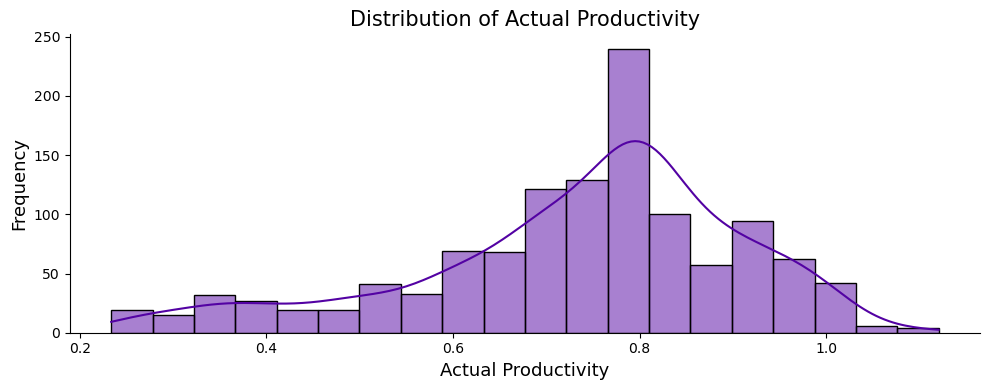

In [20]:

sns.histplot(df['actual_productivity'], 
             bins=20, 
             kde=True)

sns.despine(top=True, right=True) # quit the axes


plt.title("Distribution of Actual Productivity")
plt.xlabel("Actual Productivity")
plt.ylabel("Frequency")

plt.show()

In the productivity histogram, we can see a distribution center near 0.8. This value falls under our second productivity category, below the most desirable value.

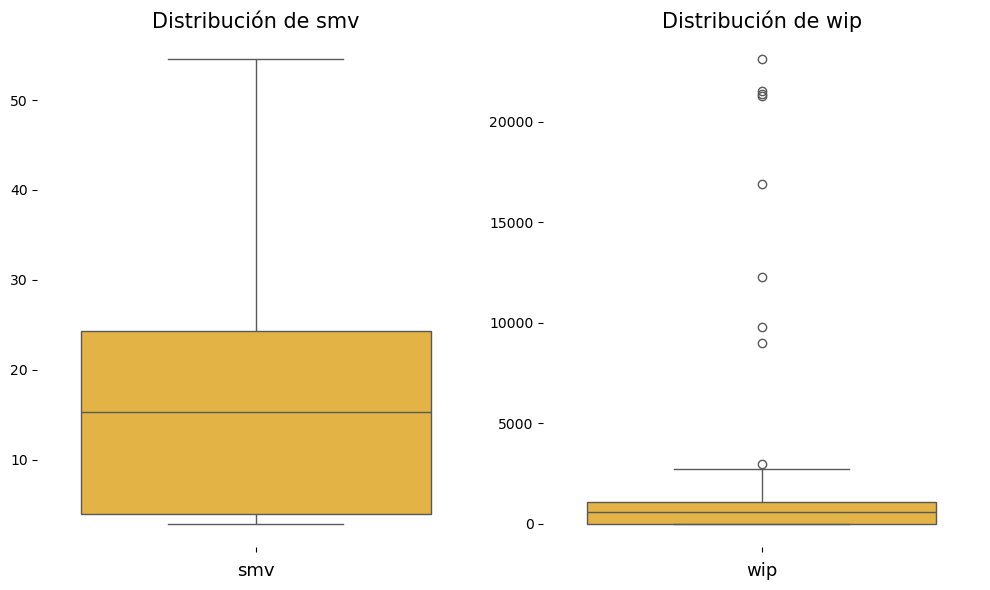

In [21]:
cols_to_plot = ['smv', 'wip'] # select columns

fig, axes = plt.subplots(nrows=1, ncols=2,figsize=(10, 6))

axes = axes.flatten() # easier iteration

for i, col in enumerate(cols_to_plot):
    sns.boxplot(data=df, y=col, ax=axes[i], color=sns.color_palette()[5])
    axes[i].set_xlabel(col)
    sns.despine(top=True, right=True,left=True, bottom=True) # quit the box
    axes[i].set_title(f'Distribución de {col}')
    
    axes[i].set_ylabel('')


plt.show()

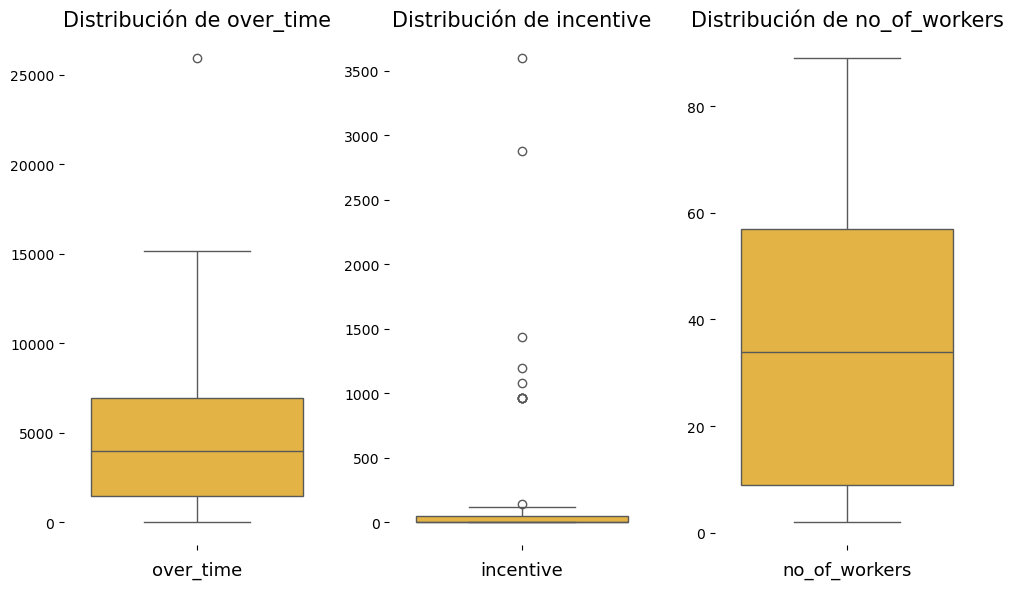

In [22]:

cols_to_plot = ['over_time',  'incentive',  'no_of_workers']


fig, axes = plt.subplots(nrows=1, ncols=3,figsize=(10, 6))

axes = axes.flatten() # easier uiteration

for i, col in enumerate(cols_to_plot):
    sns.boxplot(data=df, y=col, ax=axes[i], color=sns.color_palette()[5])
    axes[i].set_xlabel(col)
    sns.despine(top=True, right=True,left=True, bottom=True) # quit the box
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_ylabel('')


plt.show()

This boxplot shows:
- Targeted productivity and actual productivity have some outlier but will be keeped due their are posible values for these features.
- SMV, no_of workers haven't outliers.
- Incentive and wip have several high outliers. We impute them with the mean.
- Over_time has one extreme outlier. We impute them with the mean. 

In [23]:
cols_quit_outliers = ['incentive', 'over_time', 'wip']

for col in cols_quit_outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1    
    # define limits
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR    
    # median for impute
    median = df[col].median()
    df.loc[(df[col] < limite_inf) | (df[col] > limite_sup), col] = median

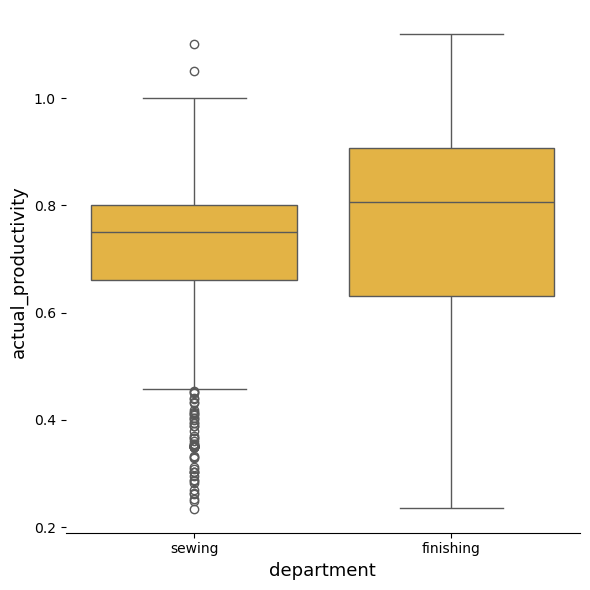

In [24]:
plt.subplots(figsize=(6, 6))
sns.boxplot(data=df, x='department', y='actual_productivity',color=sns.color_palette()[5])
sns.despine(top=True, right=True,left=True) # quit the box
plt.show()

There is little difference between the actual productivity of sewing and finishing. It is worth mentioning the more homogeneous distribution in finishing, which is evident in the short distance between quartiles compared to the outliers present in sewing.

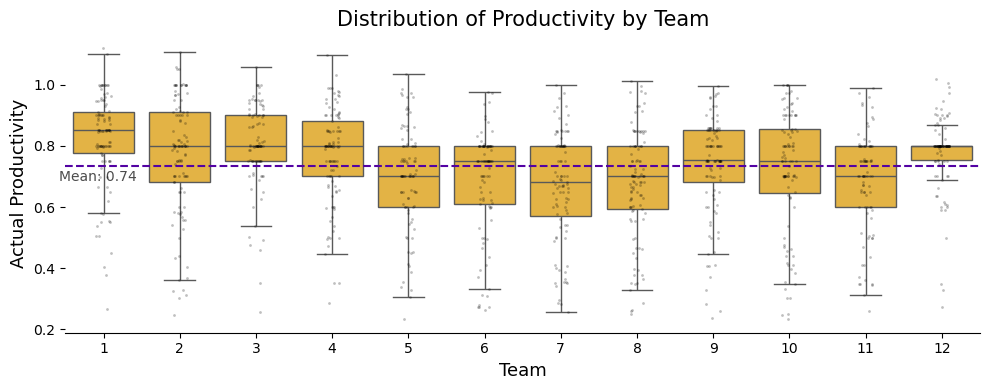

In [25]:
sns.boxplot(
    data=df,
    x='team',
    y='actual_productivity',
    showfliers=False, # quit the outliers
    color=sns.color_palette()[5]
)

sns.stripplot(
    data=df,
    x='team',
    y='actual_productivity',
    color='black',
    alpha=0.25,
    size=2
)

# Line for global media actual productivity
global_mean = df['actual_productivity'].mean()
plt.axhline(global_mean, linestyle='--')
plt.text(x=-0.58, y=global_mean - 0.05, s=f'Mean: {global_mean:.2f}', 
         color='black',  alpha=0.7)

sns.despine(top=True, right=True,left=True) # quit the box
plt.title('Distribution of Productivity by Team')
plt.xlabel('Team')
plt.ylabel('Actual Productivity')

plt.show()

In these boxplots, we can see that several teams have their mean productivity above the overall average, but all teams show a large IQR and several outliers.

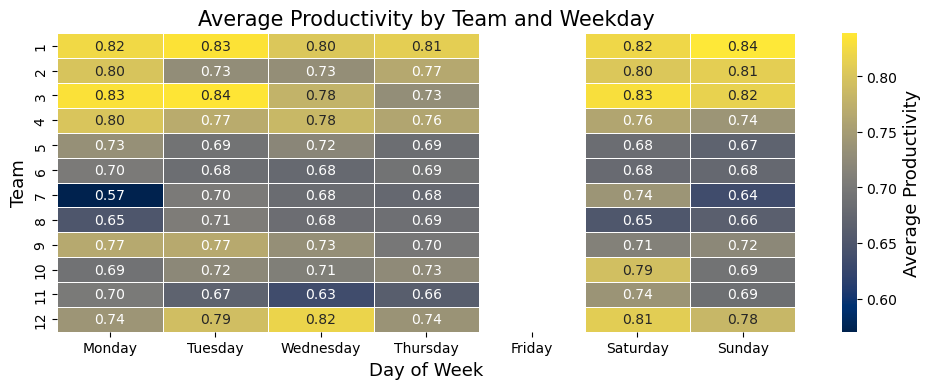

In [26]:
order_days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# convert to categorical with proper oreder
df['day'] = pd.Categorical(df['day'],
                           categories=order_days,
                           ordered=True)

# make a table grouping by team and days, take the mean, and use days as a column
pivot = (
    df.groupby(['team','day'], observed=True)['actual_productivity']
      .mean()
      .unstack()
      .reindex(columns=order_days)
)




sns.heatmap(
    pivot,
    cmap='cividis',
    annot=True,        # show values
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={'label': 'Average Productivity'}
)

plt.title('Average Productivity by Team and Weekday')
plt.xlabel('Day of Week')
plt.ylabel('Team')
plt.show()

This heatmap is another way to view the information already shown in the boxplots.

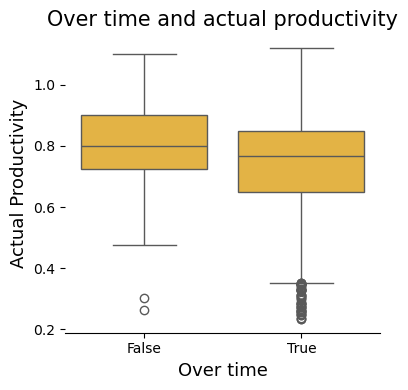

In [27]:
df['has_ot'] = df['over_time'] > 0 #make a boolean column for the plot

plt.subplots(figsize=(4, 4))
sns.boxplot(data=df,
            x='has_ot',
            y='actual_productivity',
            color=sns.color_palette()[5]);

sns.despine(top=True, right=True,left=True) # quit the box
plt.xlabel('Over time')
plt.ylabel('Actual Productivity')
plt.title('Over time and actual productivity')
plt.show()

The boxplots show that overtime seems to do not lead to an increase in productivity.

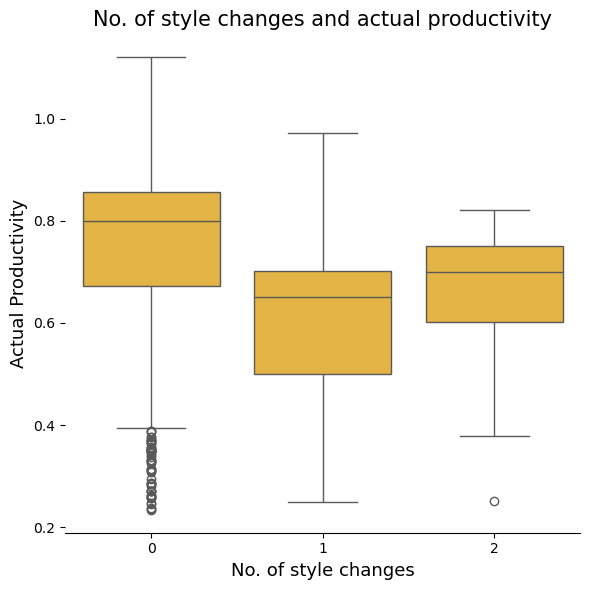

In [28]:
plt.subplots(figsize=(6, 6))
sns.boxplot(data=df, 
            x='no_of_style_change', 
            y='actual_productivity',
            color=sns.color_palette()[5])
sns.despine(top=True, right=True,left=True) # quit the box
plt.title('No. of style changes and actual productivity')
plt.xlabel('No. of style changes')
plt.ylabel('Actual Productivity')
plt.show()

By the boxplots of actual productivity grouped by number of style changes, we can see that the style changes have no clear relation with productivity

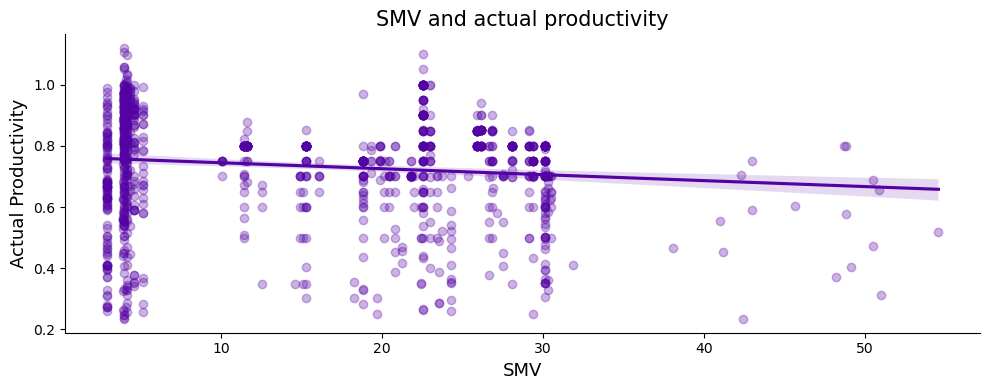

In [29]:
sns.regplot(data=df, 
            x='smv', 
            y='actual_productivity',
            scatter_kws={'alpha':0.3})
sns.despine(top=True, right=True) # quit the box
plt.title('SMV and actual productivity')
plt.xlabel('SMV')
plt.ylabel('Actual Productivity')
plt.show()


From the plot, we can see that there are typical SMV values instead of a continuous distribution.
The high heterogeneity suggests that SMV alone may not fully explain productivity, although it seems to have a negative correlation.

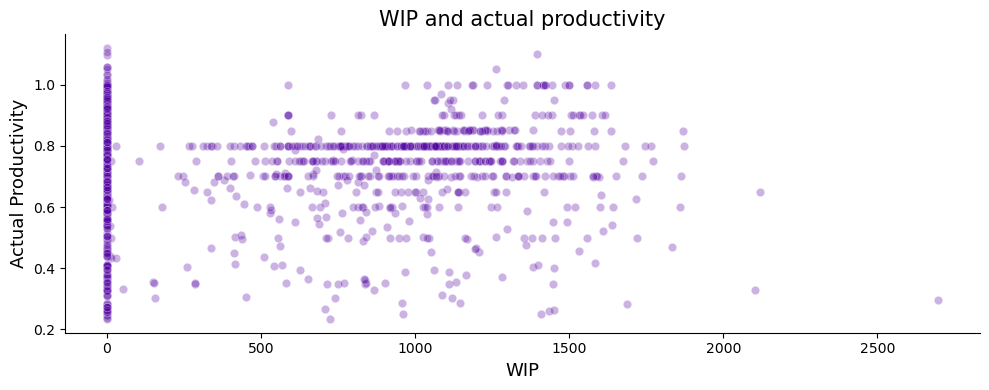

In [30]:
sns.scatterplot(data=df, x='wip', y='actual_productivity', alpha=0.3)
sns.despine(top=True, right=True) # quit the box
plt.title('WIP and actual productivity')
plt.xlabel('WIP')
plt.ylabel('Actual Productivity')
plt.show()

The relationship appears weak and the high dispersion suggests that WIP alone is not sufficient to explain productivity differences.

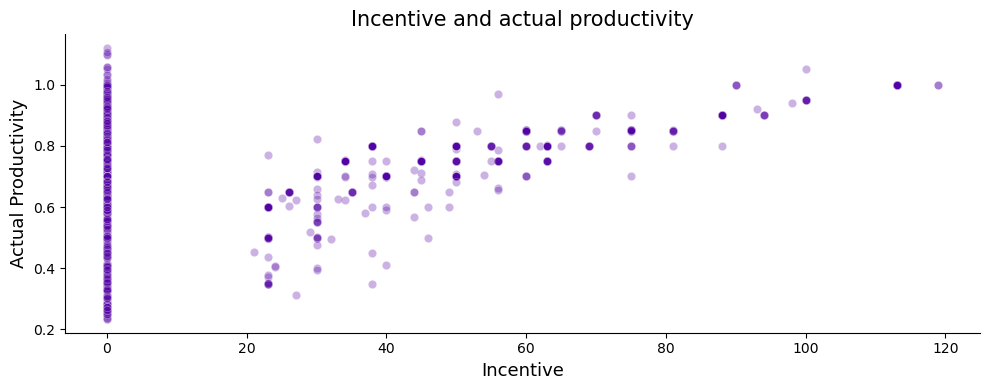

In [31]:
sns.scatterplot(data=df, x='incentive', y='actual_productivity', alpha=0.3)
sns.despine(top=True, right=True) # quit the box
plt.title('Incentive and actual productivity')
plt.xlabel('Incentive')
plt.ylabel('Actual Productivity')
plt.show()

We can see a fairly linear relationship between actual productivity and incentive (for not 0 incentive)

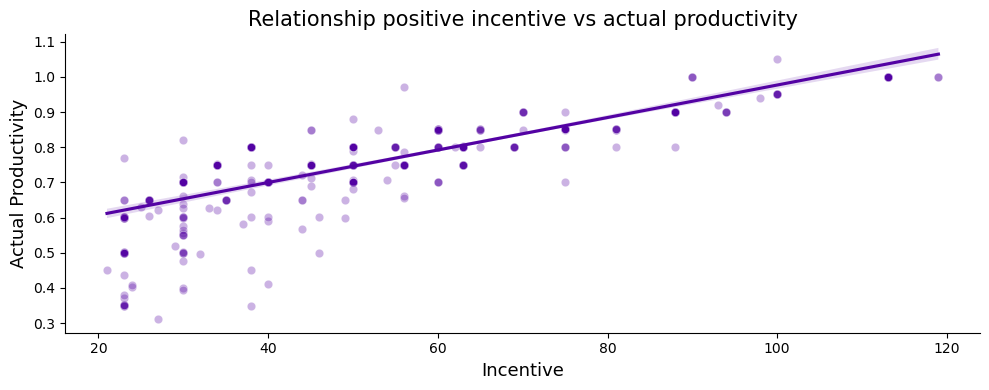

In [32]:
# plot the points wit positive incentive
sns.scatterplot(data=df[df['incentive'] > 0], x='incentive', y='actual_productivity', alpha=0.3)

# we add the linear fit
sns.regplot(data=df[df['incentive'] > 0], 
            x='incentive', 
            y='actual_productivity', 
            scatter=False)

plt.title("Relationship positive incentive vs actual productivity")
plt.xlabel('Incentive')
plt.ylabel('Actual Productivity')
sns.despine(top=True, right=True) # quit the box
plt.show()

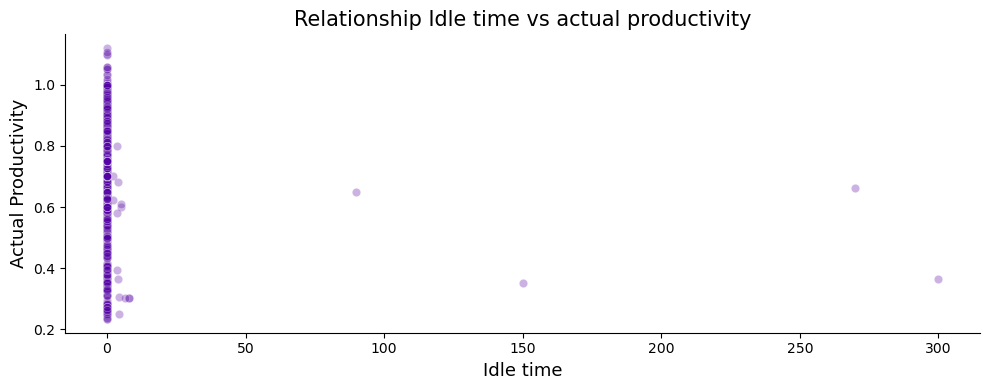

In [33]:
sns.scatterplot(data=df, x='idle_time', y='actual_productivity', alpha=0.3)
plt.title("Relationship Idle time vs actual productivity")
plt.xlabel('Idle time')
plt.ylabel('Actual Productivity')
sns.despine(top=True, right=True) # quit the box
plt.show()

In the same way than incentive, the big number of zero values makes hard to find a correlation. But, even discading the zeros, they are clustered near zero, then we apply a logarithmic scale for improve visualization.

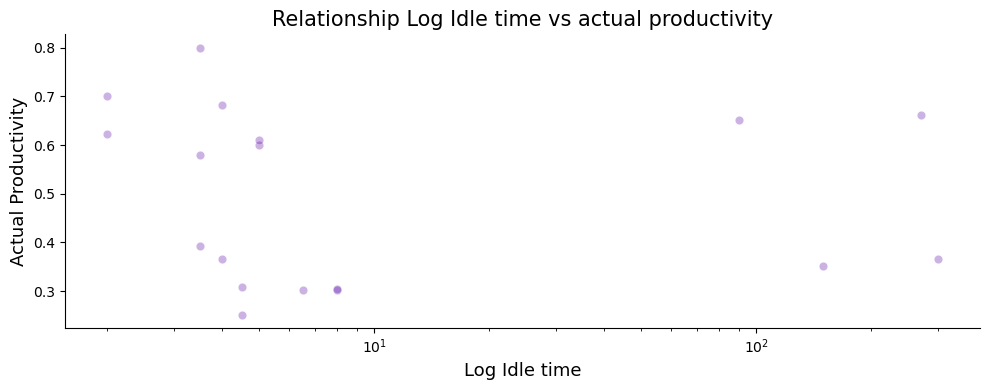

In [34]:
sns.scatterplot(data=df[df['idle_time'] > 0], x='idle_time', y='actual_productivity', alpha=0.3)
plt.title("Relationship Log Idle time vs actual productivity")
plt.xlabel('Log Idle time')
plt.ylabel('Actual Productivity')
sns.despine(top=True, right=True) # quit the box
plt.xscale('log')
plt.show()

Whether using a logarithmic scale or not, the relationship remains unclear.

We analyze the relationship between actual productivity and targeted productivity

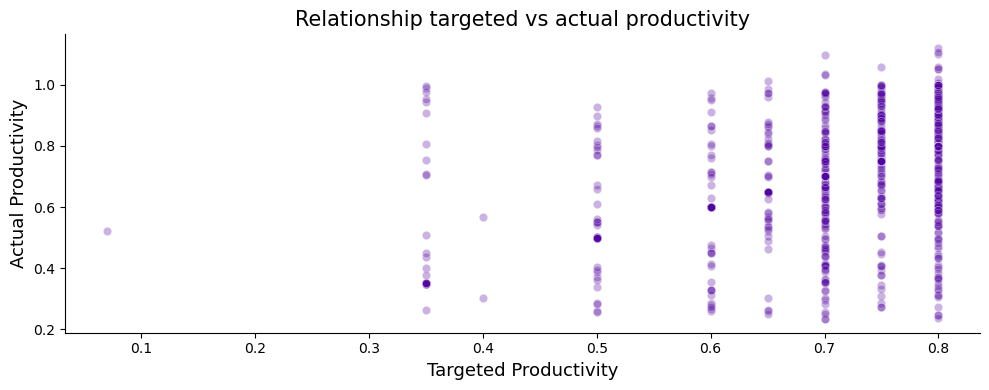

In [35]:
sns.scatterplot(data=df, x='targeted_productivity', y='actual_productivity', alpha=0.3)
plt.title("Relationship targeted vs actual productivity")
plt.xlabel('Targeted Productivity')
plt.ylabel('Actual Productivity')
sns.despine(top=True, right=True) # quit the box
plt.show()

We can observe that the numbers have a granularity of 0.05 and an upper bound at 0.8.

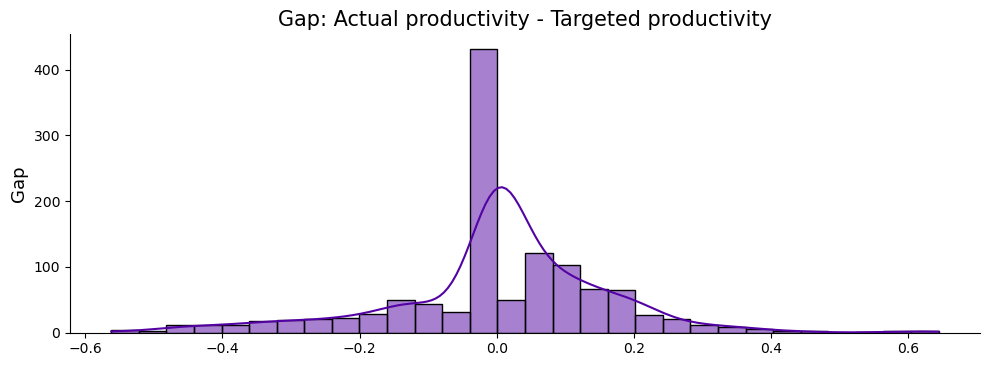

In [36]:
df['gap'] = df['actual_productivity'] - df['targeted_productivity']

sns.histplot(df['gap'],kde=True, bins=30);
plt.title("Gap: Actual productivity - Targeted productivity")
plt.xlabel(' ')
plt.ylabel('Gap')
sns.despine(top=True, right=True) # quit the box
plt.show()

The distribution of the productivity gap is approximately centered around zero, suggesting that, on average, actual productivity aligns with the targeted levels. Although slight asymmetry may be present, there is no strong evidence of systematic overestimation or underestimation in the targets.

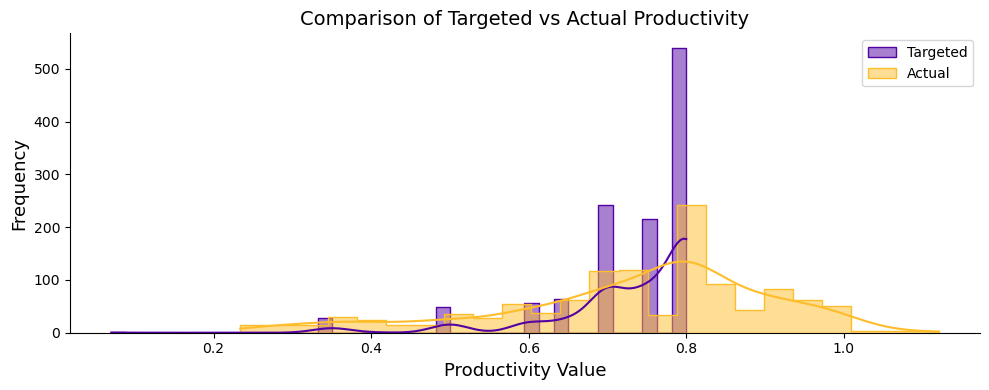

In [37]:
# Hist Targeted Productivity
sns.histplot(df['targeted_productivity'], 
             label='Targeted', 
             kde=True,
             element="step")

# Hist Actual Productivity
sns.histplot(df['actual_productivity'], 
             color=sns.color_palette()[5], 
             label='Actual', 
             kde=True, 
             element="step")


plt.title('Comparison of Targeted vs Actual Productivity', fontsize=14)
plt.xlabel('Productivity Value')
plt.ylabel('Frequency')
sns.despine(top=True, right=True) # quit the box
plt.legend() # Importante para saber cuál es cuál

sns.despine() # Quita los bordes innecesarios
plt.show()

In these histograms, we confirm that they are aligned in their mode but not in median or average. Targeted productivity has a strong ceiling and is more concentrated.

Finally, we apply a Wilcoxon Signed-Rank Test to establish the no alignment.

In [38]:
# Ho: There is no significant difference between actual and targeted productivity
# Ha: There is a significant difference
stat, p_value = stats.wilcoxon(df['actual_productivity'], df['targeted_productivity'])

print(f"Statistic: {stat:.4f}, p-value: {p_value:.4e}")

if p_value < 0.05:
    print("Significant differences exist: the goal-setting process is NOT neutral.")
else:
    print("No evidence of bias: the targets are well-aligned with reality.")

Statistic: 263027.5000, p-value: 9.9696e-15
Significant differences exist: the goal-setting process is NOT neutral.


The Wilcoxon Signed-Rank Test yielded a p-value very near 0 (9.97e-15), indicating a statistically significant difference between actual and targeted productivity. Given that the median gap is negative, we can conclude that the management is currently underestimating the production capacity of the teams

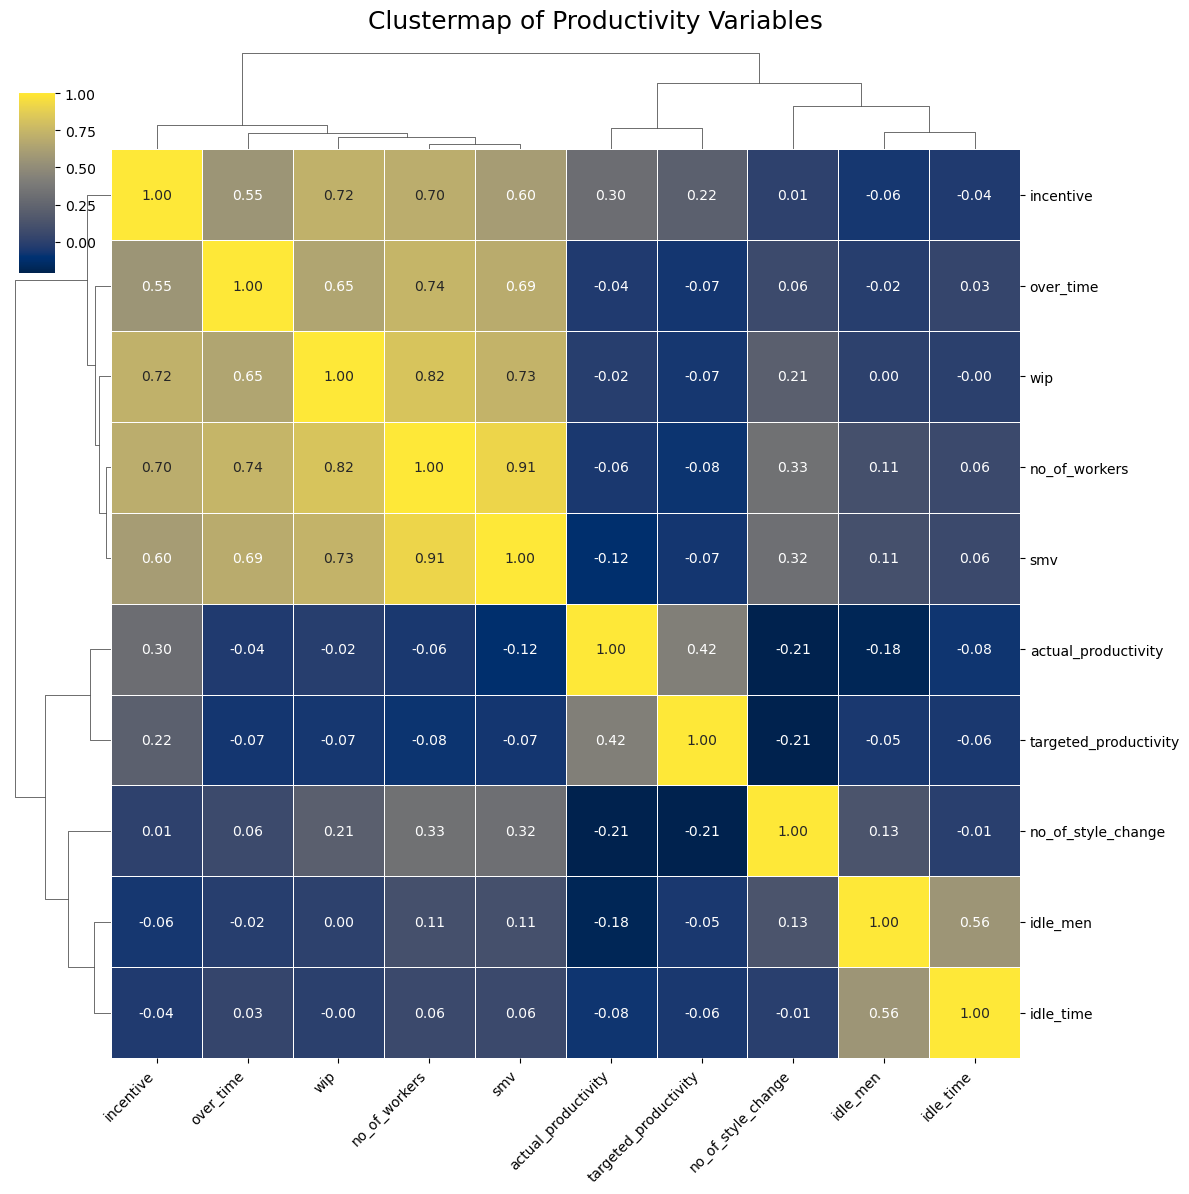

In [39]:
columns = [
    'idle_men', 'idle_time', 'no_of_workers', 
    'smv', 'wip', 'over_time', 'incentive', 
    'actual_productivity', 'targeted_productivity', 'no_of_style_change'
]

# 


correlation_matrix = df[columns].corr()
g = sns.clustermap(
    correlation_matrix,
    method='ward',      # Clustering method (minimizes variance)
    cmap='cividis',
    annot=True,
    fmt=".2f",
    figsize=(12, 12),   
    linewidths=0.5,
    dendrogram_ratio=(.1, .1), # size of "branches"
    cbar_pos=(0.02, 0.8, 0.03, 0.15) # legend position
)

plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)

g.fig.suptitle('Clustermap of Productivity Variables', fontsize=18, y=1.02)
plt.show()

Using this clustermap, we have the information usual in a correlation matrix but ordered, providing insights into the underlying structure of the data through the dendrograms.  
The data reveal a natural and very strong correlation between idle workers and idle time. We also observe significant positive correlations between the number of workers and key variables such as SMV, WIP, and overtime, as well as between WIP and incentives.

Furthermore, SMV and overtime show a notable positive correlation. While there is a positive relationship between actual and targeted productivity, it is not as strong as the operational correlations mentioned above. Finally, the most relevant negative correlation, although moderate, exists between targeted productivity and the number of style changes.

## Categorical productivity

The variable actual_productivity was discretized into four ordinal categories (1-4) to align the statistical analysis with operational performance tiers. This transformation facilitates the identification of patterns across teams, reduces the impact of minor fluctuations (noise) in measurement, and provides a clearer framework for categorical association tests such as Chi-Square or Cramer's V

In [40]:
df['prod_cat'] = pd.cut(
    df['actual_productivity'],
    bins=[0, 0.7, 0.8, 0.9, float('inf')],
    labels=[1, 2, 3, 4],
    right=False
)


In [41]:
df['prod_cat'].value_counts()

prod_cat
1    365
3    363
2    266
4    203
Name: count, dtype: int64

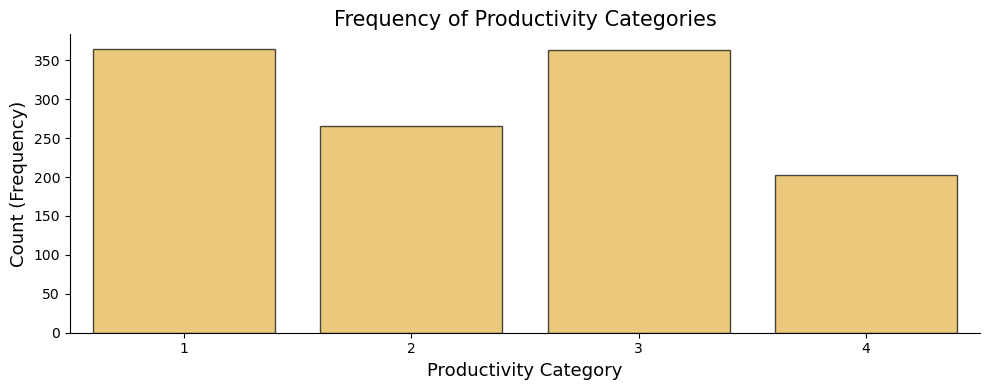

In [42]:
sns.countplot(
    data=df, 
    x='prod_cat', 
    color=sns.color_palette()[5],
    edgecolor='black', 
    alpha=0.7
)

# 3. Estética
plt.title('Frequency of Productivity Categories')
plt.xlabel('Productivity Category')
plt.ylabel('Count (Frequency)')

sns.despine() 
plt.show()

We analyze the association between 'cat_prod' and the rest of categorical variables, including 'team' and 'no_of_style_change' in categorical variables. We can do this because:  
- Despite than 'team' is numerical, has low cardinality and their orden have not meaning.
- 'no_style_change', although numeric in representation, functions as an ordinal scale. Treating the variable as categorical allows the model to capture non-linear relationships, as we saw in the boxplots vs 'actual_productivity'

In [43]:
def chicramer(var1,var2,df):
    # create contingency table
    contingency_table = pd.crosstab(df[var1], df[var2])
    
    # Chi-Square test
    chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
    
    # Cramer's V test
    n = contingency_table.sum().sum() 
    min_dim = min(contingency_table.shape) - 1 
    cramer_v = np.sqrt(chi2 / (n * min_dim))
    print(f"For variables {var1} and {var2} the results of the test are:")
    print(f"Chi2 p-value: {p:.4e}")
    print(f"Cramer's v: {cramer_v:.4f}")

variables_to_analize=['department', 'day', 'team', 'quarter','no_of_style_change']

for var in variables_to_analize:
    chicramer(var,'prod_cat',df)

For variables department and prod_cat the results of the test are:
Chi2 p-value: 4.5897e-23
Cramer's v: 0.2991
For variables day and prod_cat the results of the test are:
Chi2 p-value: 4.3980e-01
Cramer's v: 0.0650
For variables team and prod_cat the results of the test are:
Chi2 p-value: 8.1471e-25
Cramer's v: 0.2328
For variables quarter and prod_cat the results of the test are:
Chi2 p-value: 1.7601e-08
Cramer's v: 0.1299
For variables no_of_style_change and prod_cat the results of the test are:
Chi2 p-value: 7.2152e-17
Cramer's v: 0.1919


For all variables but 'day', the p-value is much smaller than 0.5. Therefore, all variables but 'day' has impact on 'prod_cat'.  From Cramer's V test, we can see that the association is weak for all variables except for 'department'.

This categorical classification of productivity allows us to have well-represented classes.

### EDA summary

Number of days: 59

Number of teams: 12

Number of registers: 1197

Data limitations:  
- Missing values: 0 (there were 506 NaN assumed as 0, according to the bibliography).
- 'no_of_workers' has some non-integer values (12% of values). Since no documentation clarifies their meaning, the variable is treated as continuous and preserved without modification
- 'actual_productivity' has a 3% of data greater than 1 and all below 1.13. As no documentation is provided, they are preserved to avoid introducing undocumented transformations.
- Incentive and wip have several high outliers. We impute them with the mean.
- Over_time has one extreme outlier. We impute them with the mean.

Production distribution by category:  
Low (under 70%): 365  
Middle-low (between 70 and 80%) 363  
Middle-high (between 80 and 90%): 266  
High (above 90%): 203  
 
Categorical features: 6 (department, day, team, quarter, date, no_of_style_change)

Numerical features: 10 (targeted_productivity, smv, wip, over_time, incentive, idle_time, idle_men,  no_of_workers, actual_productivity)

Target: prod_cat, categorical ordinal.

Note 1: the team is numerical, but its numerical value doesn't concern therefore, it is treated as categorical.
Note 2: actual_productivity must be removed for machine learning, because it will produce data leakage.

**Main observations:**
- The Wilcoxon Signed-Rank Test confirms a statistically significant bias ($p < 0.001$), revealing that targeted productivity systematically underestimates actual productivity.
- We also observe significant positive correlations between the number of workers and key variables such as SMV, WIP, and overtime, as well as between WIP and incentives.
- SMV and overtime show a notable positive correlation
- The most relevant negative correlation exists between targeted productivity and the number of style changes.
- From Chi-sqare and Cramer's V test, we can consider negligible the effect of: 'day', 'team', 'quarter'and 'no_of_style_change'.
- The data reveal a natural and very strong correlation between idle workers and idle time. 

**Save preprocessed data**

In [44]:
df.to_csv('../data/processed/dataset.csv', index=False)

## Machine Learning

In this section we uses regression techniques in order to predict the productivity based in the rest of features.

In [45]:
# load dataset
df = pd.read_csv('../data/processed/dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df['wip']=df['wip'].fillna(0)
df['prod_cat'] = pd.cut(
    df['actual_productivity'],
    bins=[0, 0.7, 0.8, 0.9, float('inf')],
    labels=[1, 2, 3, 4],
    right=False
)
RANDOM_STATE = 43 # fix random state for all the tasks

In [46]:
# Define target
target = 'prod_cat'

# Define categorical columns
categorical_cols = [
    'department', 'day', 'team', 'quarter'
]

# Define numerical columns
numeric_cols = [  'no_of_style_change',
                'smv', 'wip', 'over_time', 
                'incentive', 'idle_time', 'idle_men',
                'no_of_workers']

# separate features and target
X = df[categorical_cols + numeric_cols]
y = df['prod_cat'].astype(int)


'date' was excluded because the date can't be repeated, and we do not use temporal/seasonal information. 'no_of_style_change' was included among the numeric columns to keep their ordinal feature.
To avoid data contamination and potential confounding effects, targeted_productivity was removed from the set of predictors, as it is calculated directly from the other input variables.

We define the base models to use.

In [47]:
# define models with usual parameters
models = {
    "Ridge": Ridge(random_state=RANDOM_STATE),
    "SVR": SVR(C=1.0),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE),
    "XGBoost": XGBRegressor(objective="reg:squarederror", n_estimators=300, learning_rate=0.1, max_depth=6, random_state=RANDOM_STATE),
    "LightGBM": LGBMRegressor(n_estimators=300, learning_rate=0.1, random_state=RANDOM_STATE, verbose=-1),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=300, bootstrap=True, random_state=RANDOM_STATE),
    "KNN": KNeighborsRegressor(n_neighbors=5)
}

We split the dataset in train and test. Train will be used to choose the model and, further, to optimize hyperparameters.

In [48]:
# Divisón Train / Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

Since the regressors give us continuous estimations on the target variable but we are interested in categories, we need to define funtions to make an optimal discretization of the output.
To evaluate each base model, we perform a cross-validation with stratified k-fold over the previous training set.

In [49]:
# auxiliary functions to convert continuous prediction into discrete
def get_discrete_classes(y_cont: np.ndarray, thresholds: list) -> np.ndarray:
    """ Convert continuous predictions to classes (1, 2, 3, 4) according thresholds."""
    sorted_thresholds = np.sort(thresholds)
    return np.digitize(y_cont, sorted_thresholds) + 1

def optimize_thresholds(y_val_cont: np.ndarray, y_val_true: np.ndarray) -> np.ndarray:
    """ Fit the optimal thresholds for F1-Score Macro."""
    def loss_function(thresholds):
        preds = get_discrete_classes(y_val_cont, thresholds)
        return -cohen_kappa_score(y_val_true, preds, weights='quadratic')
    
    init_thresholds = [1.5, 2.5, 3.5]
    res = minimize(loss_function, init_thresholds, method='Nelder-Mead')
    return np.sort(res.x)

# cross validate function
def evaluate_regressors_cv(
    X: pd.DataFrame, 
    y: pd.Series, 
    numeric_cols: list, 
    categorical_cols: list, 
    models_dict: dict, 
    n_splits: int = 5, 
    random_state: int = 43
) -> pd.DataFrame:
    
    numeric_transformer = Pipeline([('scaler', StandardScaler())])
    categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
    
    preprocessor = ColumnTransformer(transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    results = []

    for model_name, regressor in models_dict.items():
        full_pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('regressor', regressor)
        ])

        fold_maes = []
        fold_f1s = []
        fold_bal_accs = []
        fold_qwks = []

        for train_idx, val_idx in skf.split(X, y):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx].values, y.iloc[val_idx].values

            model = clone(full_pipeline)
            model.fit(X_train, y_train)

            y_val_pred_cont = model.predict(X_val)
            best_thresholds = optimize_thresholds(y_val_pred_cont, y_val)
            y_val_pred_disc = get_discrete_classes(y_val_pred_cont, best_thresholds)

            # metrics for each fold
            fold_maes.append(mean_absolute_error(y_val, y_val_pred_disc))
            fold_f1s.append(f1_score(y_val, y_val_pred_disc, average='macro', zero_division=0))
            fold_bal_accs.append(balanced_accuracy_score(y_val, y_val_pred_disc))
            fold_qwks.append(cohen_kappa_score(y_val, y_val_pred_disc, weights='quadratic'))

        results.append({
            "Model": model_name,
            "MAE Mean": np.mean(fold_maes),
            "F1-Macro Mean": np.mean(fold_f1s),
            "Bal Accuracy Mean": np.mean(fold_bal_accs),
            "QWK Mean": np.mean(fold_qwks),
            "QWK Std": np.std(fold_qwks)
        })

    return pd.DataFrame(results).sort_values(by="QWK Mean", ascending=False)

To evaluate the performance of models we use five metrics:

**MAE Mean (Mean Absolute Error):** Measures the average magnitude of continuous errors ($\vert{}y - \hat{y}\vert{}$). Lower values indicate better performance, as it reflects predictions closer to the true target values.

**F1-Macro Mean:** The unweighted average of F1-Scores across all categories. It evaluates how effectively the model classifies every class without bias toward majority tiers, balancing both Precision (avoiding false alarms) and Recall (capturing true cases).

**Bal Accuracy Mean (Balanced Accuracy):** The average Recall across all individual classes. It measures the percentage of real instances correctly identified within each productivity tier, preventing minority classes from being overlooked.

**QWK Mean (Quadratic Weighted Kappa):** The primary metric for ordinal classification. It quantifies the agreement between ground-truth labels and predictions while penalizing distant misclassifications quadratically (e.g., predicting Class 4 for a Class 1 target is penalized far more heavily than predicting Class 2).

**QWK Std:** Measures the variance/instability of the QWK score across Cross-Validation folds. Lower values indicate a robust, reliable model whose performance does not depend on data splitting luck.

In [50]:
df_results = evaluate_regressors_cv(X_train, y_train, numeric_cols, categorical_cols, models, random_state=RANDOM_STATE)
print(df_results)

          Model  MAE Mean  F1-Macro Mean  Bal Accuracy Mean  QWK Mean  \
2  RandomForest  0.421079       0.625561           0.618072  0.719726   
5    ExtraTrees  0.417926       0.635635           0.628540  0.715600   
4      LightGBM  0.453474       0.601789           0.597515  0.691568   
3       XGBoost  0.450338       0.626413           0.618916  0.683903   
1           SVR  0.535989       0.547909           0.540322  0.620074   
0         Ridge  0.650000       0.449097           0.456680  0.565161   
6           KNN  0.625889       0.447813           0.453113  0.538690   

    QWK Std  
2  0.020389  
5  0.049439  
4  0.034458  
3  0.045210  
1  0.081097  
0  0.040062  
6  0.045878  


Clearly, the two best-performing models are RandomForestRegressor and ExtraTreesRegressor. Although ExtraTrees achieves slightly better MAE, F1-Macro, and Balanced Accuracy, we select RandomForest. This decision is driven by the fact that QWK is our primary domain-specific metric, and RandomForest demonstrates greater stability, with a QWK standard deviation less than half that of ExtraTrees.

Now we optimize hyperparameters and threshold for RandomForestRegressor.

We evaluate hyperparameter combinations using MAE (scoring='neg_mean_absolute_error') because it is the only standard, out-of-the-box scikit-learn regressor metric that respects ordinal distance.

This provides a direct and reliable benchmark for hyperparameter search before calibrating custom QWK thresholds in post-processing.

In [51]:
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([('scaler', StandardScaler())]), numeric_cols),
    ('cat', OneHotEncoder( handle_unknown='ignore', sparse_output=False), categorical_cols)
])

pipe_final = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(random_state=RANDOM_STATE))
])

param_distributions = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 6, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ['sqrt', 'log2', 1.0],
    "model__bootstrap": [True, False]
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    estimator=pipe_final, 
    param_distributions=param_distributions, 
    n_iter=25, 
    cv=skf,
    scoring='neg_mean_absolute_error',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_
print(f"Best parameters: {search.best_params_}")

# optimize the thresholds for the optimized model
y_train_pred_cont = cross_val_predict(best_model, X_train, y_train, cv=skf, n_jobs=-1)
best_thresholds = optimize_thresholds(y_train_pred_cont, y_train)

y_train_pred_disc = get_discrete_classes(y_train_pred_cont, best_thresholds)

print("\n--- Metrics obtained in train set for optimal parameters ---")
print(f"Optimal thresholds: {best_thresholds}")
print(f"MAE:               {mean_absolute_error(y_train, y_train_pred_disc):.4f}")
print(f"F1-Score (macro):  {f1_score(y_train, y_train_pred_disc, average='macro'):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_train, y_train_pred_disc):.4f}")
print(f"QWK (Quadratic):   {cohen_kappa_score(y_train, y_train_pred_disc, weights='quadratic'):.4f}")

Best parameters: {'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 1.0, 'model__max_depth': 20, 'model__bootstrap': True}

--- Metrics obtained in train set for optimal parameters ---
Optimal thresholds: [1.69988433 2.38655666 3.26305718]
MAE:               0.4326
F1-Score (macro):  0.6271
Balanced Accuracy: 0.6174
QWK (Quadratic):   0.7128


### Model Results and Evaluation

We compute the metrics of our best model in the test set

In [52]:
# Obtain the continuous predictions on test
y_test_pred_cont= best_model.predict(X_test)

# Discretize the predictions
y_pred = get_discrete_classes(y_test_pred_cont, best_thresholds)

# show metrics
print("Metrics obtained in test set for optimal parameters")
print(f"Threshods used (optimized over train): {best_thresholds}")
print(f"MAE:               {mean_absolute_error(y_test, y_pred):.4f}")
print(f"F1-Score (macro):  {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}")
print(f"QWK (Quadratic):   {cohen_kappa_score(y_test, y_pred, weights='quadratic'):.4f}")

# detailed report for each class
print("\n Classification report")
print(classification_report(y_test, y_pred, digits=4))

Metrics obtained in test set for optimal parameters
Threshods used (optimized over train): [1.69988433 2.38655666 3.26305718]
MAE:               0.4792
F1-Score (macro):  0.6113
Balanced Accuracy: 0.6046
QWK (Quadratic):   0.6606

 Classification report
              precision    recall  f1-score   support

           1     0.7213    0.6027    0.6567        73
           2     0.4915    0.5472    0.5179        53
           3     0.6196    0.7808    0.6909        73
           4     0.7143    0.4878    0.5797        41

    accuracy                         0.6250       240
   macro avg     0.6367    0.6046    0.6113       240
weighted avg     0.6384    0.6250    0.6233       240



Test set metrics confirm that the model generalizes well without severe overfitting, holding a strong QWK of 0.6485. Performance is solid across classes 1–3, though class 4 exhibits lower recall due to its smaller sample size.

Using our best model and parameters we analize the results obtained, comparing actual productivity and predicted productivity.

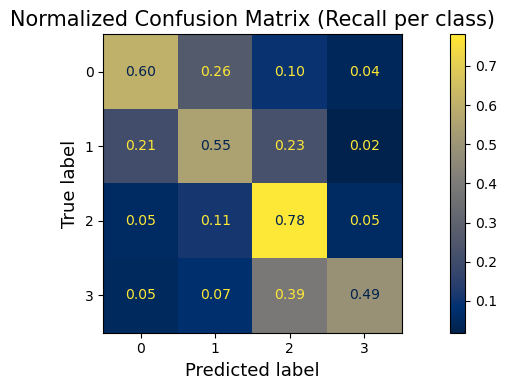

In [53]:
cm_norm = confusion_matrix(y_test, y_pred, normalize="true")

disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
disp.plot(cmap='cividis',
    values_format='.2f', 
    ax=plt.gca(),        
    colorbar=True        
)

plt.title("Normalized Confusion Matrix (Recall per class)")
plt.show()

The normalized confusion matrix provides a clear, scale-invariant view of model performance by evaluating recall across all ordinal classes. It clearly highlights that while Class 3 achieves the highest recall (78%), Class 4 suffers from a 61% misclassification rate into the adjacent lower class, directly confirming the model's conservative bias.

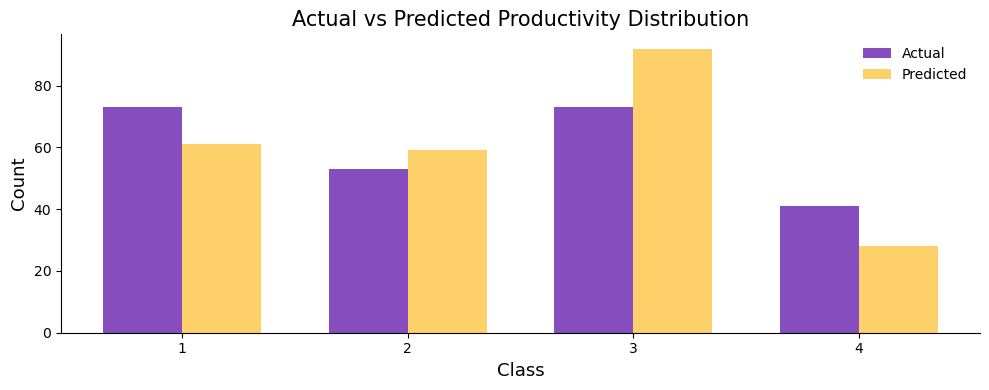

In [54]:
classes = np.unique(y_test)

real_counts = [np.sum(y_test == c) for c in classes]
pred_counts = [np.sum(y_pred == c) for c in classes]

x = np.arange(len(classes))
width = 0.35

plt.figure()
plt.bar(x - width/2, real_counts, width, label="Actual",alpha=0.7)
plt.bar(x + width/2, pred_counts, width, label="Predicted",color=sns.color_palette()[5],alpha=0.7)

sns.despine() 
plt.xticks(x, classes)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Actual vs Predicted Productivity Distribution")
plt.legend(frameon=False)
plt.show()

The higher concentration of predictions in central categories (Classes 2 and 3) reflects a conservative strategy driven by the optimization of QWK and MAE, which heavily penalize large ordinal distance errors. To minimize expected loss, the model shrinks predictions toward the center of the distribution, systematically avoiding extreme classifications—particularly Class 4—to prevent high-cost off-diagonal mistakes.

Analyzing the distance between predicted and actual labels reveals a decreasing frequency, which is a positive indicator for the model's performance.

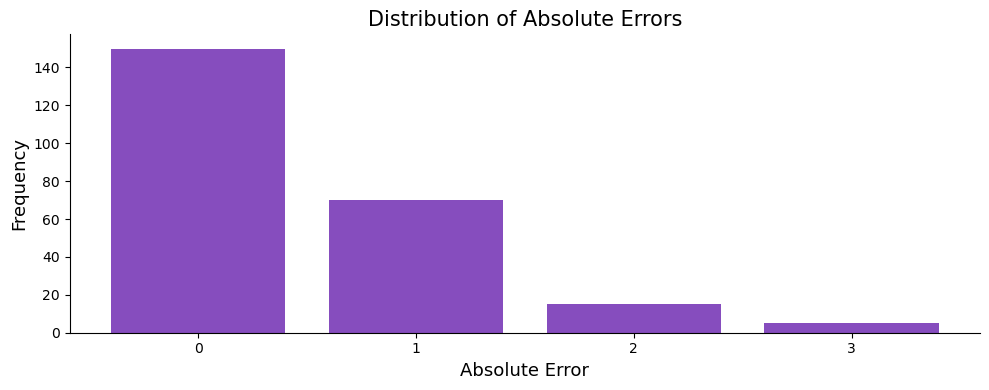

In [55]:
abs_errors = np.abs(y_test - y_pred)

# possible values (0,1,2,3)
error_values = np.arange(abs_errors.max() + 1)

# count
counts = [np.sum(abs_errors == i) for i in error_values]

plt.figure()

plt.bar(error_values, counts,alpha=0.7)
plt.xticks(error_values)  
sns.despine() 
plt.xlabel("Absolute Error")
plt.ylabel("Frequency")
plt.title("Distribution of Absolute Errors")
plt.show()


Finally, we analize the feature importance

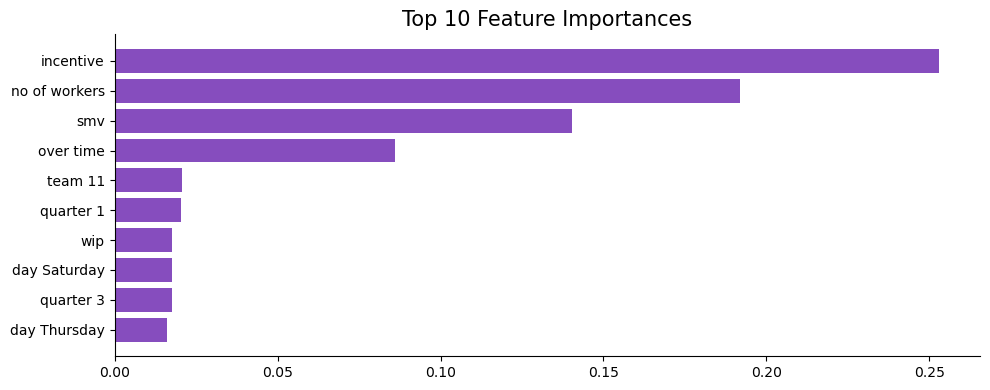

In [56]:
final_model = best_model.named_steps["model"]

importances = final_model.feature_importances_
feature_names = best_model.named_steps["preprocess"].get_feature_names_out()
display_names=[]
for feat_name in feature_names:
    base_name = feat_name.split("__")[-1]          # quit prefix num__ o cat__
    if base_name in df.columns:
         display_names.append(base_name.replace("_", " "))
    else:
        display_names.append(base_name.replace("_", " "))  # fallback al nombre transformado


feat_imp = pd.DataFrame({
    "Feature": display_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Top 10
top10 = feat_imp.head(10)

plt.figure()
plt.barh(top10["Feature"], top10["Importance"], alpha=0.7)
sns.despine() 
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances")
plt.show()

Financial incentive stands out as the dominant predictor of productivity, followed by a secondary tier formed by team size (no of workers), workload (smv), and over time. The remaining features show noticeably lower relevance in driving model decisions.

To analyze individual predictions, we will use SHAP. SHAP builds on Shapley values from cooperative game theory, which provide a mathematically principled way to distribute 'credit' among players in a game. In our problem, the 'game' is making the prediction, and the 'players' are the features. Each feature gets credit based on its marginal contribution across all possible feature combinations. To do this, we initialize a TreeExplainer directly on our fitted pipeline.

In [57]:
# extract model and preprocessor
final_model = best_model.named_steps['model']
preprocessor = best_model.named_steps["preprocess"]

# transform data
X_train_transformed = preprocessor.transform(X_train)

# get transformed feature names
feature_names = preprocessor.get_feature_names_out()

# make a dataframe of transformed
X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=feature_names)

# create explainer with train data
explainer = shap.TreeExplainer(final_model)

We analize the sample with index 1 of our test set, for this sample the features and prediction are:

In [58]:
display(X_test.iloc[[1]])
display(y_test.iloc[[1]])

,department,day,team,quarter,no_of_style_change,smv,wip,over_time,incentive,idle_time,idle_men,no_of_workers
192,sewing,Sunday,5,2,0,20.79,1208.0,7980,0,0.0,0,57.0


192    1
Name: prod_cat, dtype: int64

The next plot shows that, by default, each sample has a probability of being classified in each category (shown as $E[f(x)]$). The value of each feature pushes the probability up or down, according to the arrow. The color of the arrow indicates if the present value of the features is high (red) or low (blue) with respect to the dataset.

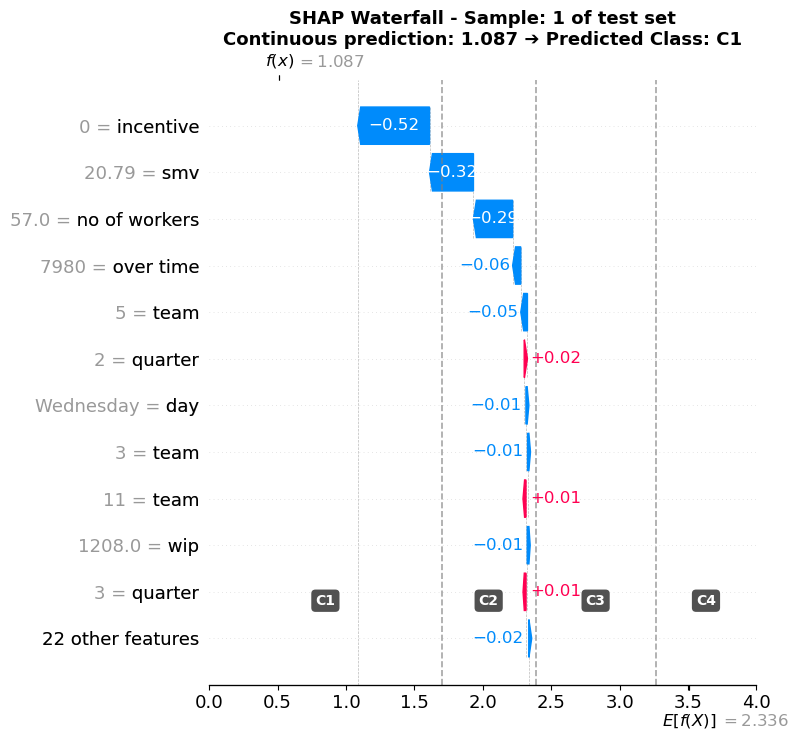

In [59]:
def plot_waterfall(sample, preprocessor, model, explainer, thresholds, sample_name=''):
    ''' This function take a sample of data, calculate Shapley values and plot a waterfall for 
    category in order to show the impact of each feature in the final prediction. Furthermore,
    threshold boundaries are depicted
    Variables:
    sample: pd.DataFrame
        A single-row DataFrame with the sample of variables to predict and analize.
    model: Estimator
        The model used for predictions
    preprocessor: ColumnTransformer / Pipeline
        The preprocessor used for transform the data.
    explainer: shap.Explainer
        The Shapley explainer trained with data and model.
    thresholds: list or array-like
        A list of thresholds among categories.
    sample_name: str, optional
        A string for the title.'''
    
    # transform the sample
    sample_transformed = preprocessor.transform(sample)
    feature_names = preprocessor.get_feature_names_out()
    sample_transformed_df = pd.DataFrame(sample_transformed, columns=feature_names)

    # make the continuos prediction and discretize
    pred_cont = model.predict(sample_transformed_df.values)[0]
    pred_class = get_discrete_classes(np.array([pred_cont]), thresholds)[0]
    
    # obtain SHAP Values
    shap_values = explainer(sample_transformed_df)
    
    # prepare for plot
    display_data = []
    display_names = []

    for feat_name in feature_names:
        base_name = feat_name.split("__")[-1]
        
        if base_name in sample.columns:
            value = sample[base_name].iloc[0]
            display_data.append(value)
            display_names.append(base_name.replace("_", " "))
        else:
            parts = base_name.split('_', 1)
            display_data.append(parts[1] if len(parts) > 1 else parts[0])
            display_names.append(parts[0].replace("_", " "))

    exp = shap.Explanation(
        values=shap_values.values[0], 
        base_values=shap_values.base_values[0],
        data=np.array(display_data), 
        feature_names=display_names
    )

    # plot axes
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # waterfall plot
    shap.plots.waterfall(exp, max_display=12, show=False)
    
    # set axes limit
    ax.set_xlim(0, 4)
    
    # Set thresholds
    for t in thresholds:
        ax.axvline(x=t, color='gray', linestyle='--', linewidth=1.2, alpha=0.7, zorder=1)

    class_bounds = [0] + list(thresholds) + [4]
    
    y_top = ax.get_ylim()[1]
    
    # class labels
    for i in range(4):
        mid_point = (class_bounds[i] + class_bounds[i+1]) / 2
        
        ax.text(
            mid_point, y_top * 0.08, f"C{i+1}", 
            color='white', fontweight='bold', fontsize=10, 
            ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#333333', alpha=0.85, edgecolor='none')
        )

    plt.title(
        f"SHAP Waterfall - Sample: {sample_name}\nContinuous prediction: {pred_cont:.3f} ➔ Predicted Class: C{pred_class}", 
        fontsize=13, fontweight='bold', pad=25
    )
    
    plt.tight_layout()
    plt.show()

plot_waterfall(
    X_test.iloc[[1]], 
    preprocessor, 
    final_model, 
    explainer, 
    best_thresholds, 
    '1 of test set'
)

We observe that, a priori, the most probable class is 2 (because  $E(F(x))=2.336$), but the prediction is obtained by summing this a priori probability with the effect of all the features. We analyze the impact of the most relevant features:
- 'incentive' with a value of 0 pushes down the expected productivity the hardest.
- 'smv' and 'no_of_workers': have a similar effect with less force.
- 'over_time': goes in the same direction, but with less strength.
- The rest of the features have low impact.
Let's say: the top 4 feature importances have a negative effect.
After summing up all these effects, we obtain a continuous prediction of 1.07, which belongs to Class 1.

Finally, we compare our model’s predictions against both actual productivity (y_test) and targeted productivity (y_targeted).

In [60]:
df_test = df.loc[X_test.index]

y_targeted = df_test['targeted_productivity'].astype('float')

y_targeted = pd.cut(
    df_test['targeted_productivity'],
    bins=[0, 0.7, 0.8, 0.9, float('inf')],
    labels=[ 1, 2, 3,4],
    right=False
).astype('float')

# Calculate metrics
metrics_data = {
    "Accuracy": [
        accuracy_score(y_test, y_targeted),
        accuracy_score(y_test, y_pred)
    ],
    "MAE": [
        mean_absolute_error(y_test, y_targeted),
        mean_absolute_error(y_test, y_pred)
    ],
    "Macro F1-Score": [
        f1_score(y_test, y_targeted, average='macro', zero_division=0),
        f1_score(y_test, y_pred, average='macro', zero_division=0)
    ],
    "Weighted F1-Score": [
        f1_score(y_test, y_targeted, average='weighted', zero_division=0),
        f1_score(y_test, y_pred, average='weighted', zero_division=0)
    ]
}

# create a dataframe with the data
df_metrics = pd.DataFrame(metrics_data, index=["Targeted (Human)", "Predicted (ML)"]).T

# Lift (%) and error reduction (%) calculus
# for mae the calculus is reversed
df_metrics["Improvement / Lift (%)"] = [
    ((df_metrics.loc["Accuracy", "Predicted (ML)"] - df_metrics.loc["Accuracy", "Targeted (Human)"]) / df_metrics.loc["Accuracy", "Targeted (Human)"]) * 100,
    ((df_metrics.loc["MAE", "Targeted (Human)"] - df_metrics.loc["MAE", "Predicted (ML)"]) / df_metrics.loc["MAE", "Targeted (Human)"]) * 100,  # Error reduction
    ((df_metrics.loc["Macro F1-Score", "Predicted (ML)"] - df_metrics.loc["Macro F1-Score", "Targeted (Human)"]) / df_metrics.loc["Macro F1-Score", "Targeted (Human)"]) * 100,
    ((df_metrics.loc["Weighted F1-Score", "Predicted (ML)"] - df_metrics.loc["Weighted F1-Score", "Targeted (Human)"]) / df_metrics.loc["Weighted F1-Score", "Targeted (Human)"]) * 100
]

# show reuslts
print("=== MODEL VS. TARGETED PERFORMANCE COMPARISON ===")
for metric in df_metrics.index:
    target_val = df_metrics.loc[metric, "Targeted (Human)"]
    pred_val = df_metrics.loc[metric, "Predicted (ML)"]
    imp_val = df_metrics.loc[metric, "Improvement / Lift (%)"]
    
    if metric == "MAE":
        print(f"{metric:<18} | Target: {target_val:.4f} | Model: {pred_val:.4f} | Error Reduction: {imp_val:.2f}%")
    else:
        print(f"{metric:<18} | Target: {target_val:.2%} | Model: {pred_val:.2%} | Lift: {imp_val:.2f}%")

=== MODEL VS. TARGETED PERFORMANCE COMPARISON ===
Accuracy           | Target: 46.25% | Model: 62.50% | Lift: 35.14%
MAE                | Target: 0.7208 | Model: 0.4792 | Error Reduction: 33.53%
Macro F1-Score     | Target: 36.30% | Model: 61.13% | Lift: 68.39%
Weighted F1-Score  | Target: 39.44% | Model: 62.33% | Lift: 58.05%


In [61]:
# y_test: actual values, y_pred: predicted productivity in classes by the model
reporte = classification_report(y_test, y_pred, zero_division=0)
print(reporte)

              precision    recall  f1-score   support

           1       0.72      0.60      0.66        73
           2       0.49      0.55      0.52        53
           3       0.62      0.78      0.69        73
           4       0.71      0.49      0.58        41

    accuracy                           0.62       240
   macro avg       0.64      0.60      0.61       240
weighted avg       0.64      0.62      0.62       240



In [62]:

# y_test: actual values, y_targeted: targeted productivity in classes
reporte = classification_report(y_test, y_targeted, zero_division=0)
print(reporte)

              precision    recall  f1-score   support

           1       0.63      0.23      0.34        73
           2       0.44      0.79      0.57        53
           3       0.44      0.71      0.54        73
           4       0.00      0.00      0.00        41

    accuracy                           0.46       240
   macro avg       0.38      0.43      0.36       240
weighted avg       0.42      0.46      0.39       240



Our Random Forest model delivers a decisive operational upgrade over traditional target setting, achieving a 35.14% lift in overall accuracy (62.50% vs. 46.25%) and a 33.53% reduction in Mean Absolute Error (0.4792 vs. 0.7208). The classification metrics further highlight this operational superiority: while official targets suffer from a critical blind spot in high-productivity shifts—completely failing to predict Class 4 instances (0.00 F1-score) and over-relying on middle tiers—our model captures Class 4 capacity with 71% precision and yields a balanced 61.13% Macro F1-score across all performance levels.

### Machine Learning Summary

**Models Evaluated:** Ridge Regressor, Random Forest Regressor, XGB Regressor, LGBM Regressor, Extra Trees Regressor, K-Neighbors Regressor.<br>
**Preprocessing:** StandardScaler for numerical variables and OneHotEncoder for categorical variables.<br>
**Data Split:** Stratified Train-Test split (80% - 20%).<br>
**Model Selection:** Conducted using **Cross-Validation with Pipelines** to prevent data leakage.<br>
**Final Model: Random Forest Regressor** was selected based on the QWK metric.<br>
**Hyperparameter Tuning:** Performed via RandomizedSearchCV on train set.<br>  
MAE (Train): 0.4305<br>
QWK (Train): 0.7145<br>
**MAE (Test): 0.4833**<br>
**QWK (Test): 0.6485**

**Feature Importance & Insights:** <br>
Based on feature importances and SHAP values, we observed the following:<br>
- incentive is the main feature.
- smv, no of workers and over time are the next features descending in importance.
- The rest of the features have lower relevance.
- The impact of each variable is different in terms of sense and with high interaction with other variables.
- The distribution of errors shows that large misclassifications are extremely rare, with most errors occurring between adjacent classes (average deviation of less than half a class: MAE = 0.48).

**Benchmark Comparison (Model vs. Targeted Productivity):** <br>
- Overall Performance: The ML model achieves 62.50% Accuracy and an MAE of 0.4792, representing a 35.14% accuracy lift and a 33.53% error reduction over traditional human targets (46.25% Accuracy, 0.7208 MAE).<br>
- Macro & Weighted F1-Scores: Outperforms human targets in both Macro F1 (0.6113 vs. 0.3630, a 68.39% lift) and Weighted F1 (0.6233 vs. 0.3944, a 58.05% lift).<br>
Class-Level Breakdown:<br>
- Classes 1, 2, & 3: Maintains strong, balanced performance across baseline and intermediate tiers, achieving solid F1-scores (0.66, 0.52, and 0.69 respectively).-
- Class 4 (High Productivity): Official targets completely fail to identify Class 4 shifts (0.00 Precision / Recall / F1), whereas the ML model effectively captures them with 71% Precision (0.58 F1-score).<br>


## Industrial implications

In the garment industry, by traditional methods, they calculate the expected productivity (in our dataset: targeted productivity). Our model also provides an expected productivity by class. In this section we compare the quality of both estimations using the classes determined for our machine learning model.

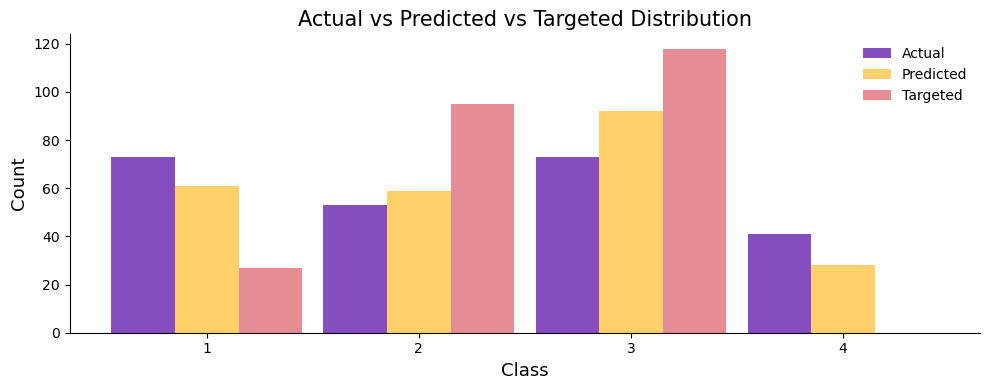

In [63]:
classes = np.unique(y_test)


# count frequences
actal_counts = [np.sum(y_test == c) for c in classes]
pred_counts = [np.sum(y_pred == c) for c in classes]
targ_counts = [np.sum(y_targeted == c) for c in classes]

x = np.arange(len(classes))
width = 0.3

plt.figure()
plt.bar(x - width, actal_counts, width, label="Actual",alpha=0.7)
plt.bar(x , pred_counts, width, label="Predicted",color=sns.color_palette()[5],alpha=0.7)
plt.bar(x + width, targ_counts, width, label="Targeted",color=sns.color_palette()[3],alpha=0.7)

plt.xticks(x, classes)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Actual vs Predicted vs Targeted Distribution")
sns.despine()
plt.legend(frameon=False)
plt.show()

It is clear that our prediction is better than targeted distribution, for measuring that we count the disctance of eache prediction with the actual value. We count the frequency of each possible distance for the targeted and predicted productivity

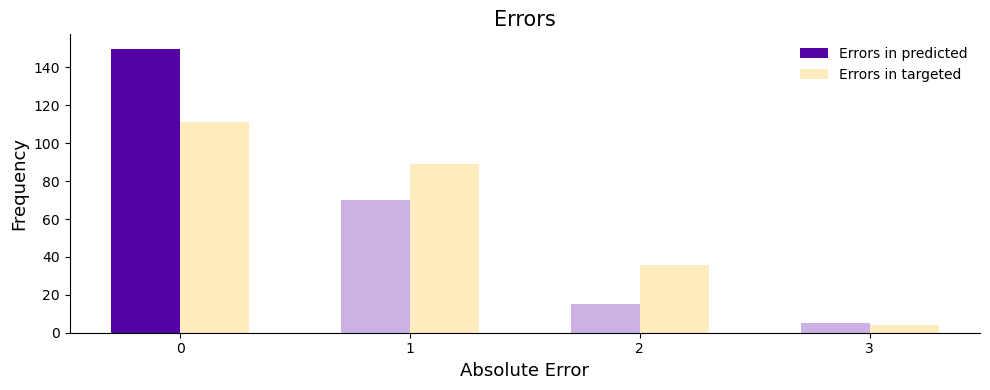

In [64]:
abs_errors_pred = np.abs(y_test -y_pred)
abs_errors_targ = np.abs(y_test - y_targeted)

# possible values (0,1,2,3)
error_values = np.arange(abs_errors_pred.max() + 1)

# Count
counts_pred = [np.sum(abs_errors_pred == i) for i in error_values]
counts_targ = [np.sum(abs_errors_targ == i) for i in error_values]

fig, ax = plt.subplots()
width = 0.3
pred_bar = ax.bar(error_values- width/2, counts_pred,width, label="Errors in predicted")
targ_bar = ax.bar(error_values+ width/2, counts_targ,width, label="Errors in targeted",color=sns.color_palette()[5])


opacity_faded = 0.3 # for fade bars
# first bar normal, the rest: faded
for i, bar in enumerate(pred_bar):
    if i != 0:  
        bar.set_alpha(opacity_faded)
    
for bar in targ_bar:
    bar.set_alpha(opacity_faded)
    
plt.xticks(error_values)  # ticks enteros
sns.despine()
plt.legend(frameon=False)
plt.xlabel("Absolute Error")
plt.ylabel("Frequency")
plt.title("Errors")
plt.show()


In this plot, a 0 value means a correct prediction, and the other values is the distance between the actual and predicted class. Only in distance 3, our prediction has more errors.

In [65]:
acc_target = accuracy_score(y_test, y_targeted)

acc_model = accuracy_score(y_test, y_pred)

lift = (acc_model - acc_target) / acc_target * 100

print(f"Accuracy of targeted productivity: {acc_target:.2%}")
print(f"Accuracy of predicted productivity: {acc_model:.2%}")
print(f"Lift: {lift:.2f}%")

Accuracy of targeted productivity: 46.25%
Accuracy of predicted productivity: 62.50%
Lift: 35.14%


Therefore, our prediction is a better tool than the traditional method with lift of 34.23%.

### A tool for improving production

Furthermore, using the shap waterfalls the garment authorities could set some parameters in order to achive a better productivity. Let analyze an example:



Let consider the next situation:<br>
    'quarter': 1<br>
    'department': sewing	<br>
    'day': Tuesday	<br>
    'team': 3	<br>
    'targeted_productivity': 0.8	<br>
    'smv': 22.52	<br>
    'wip': 1112.0	<br>
    'over_time': 6840	<br>
    'incentive': 0	<br>
    'idle_time': 0.0	<br>
    'idle_men': 0  <br>
    'no_of_style_change': 0   <br>
    'no_of_workers': 57.0<br>

If we apply our predictor, we obtain

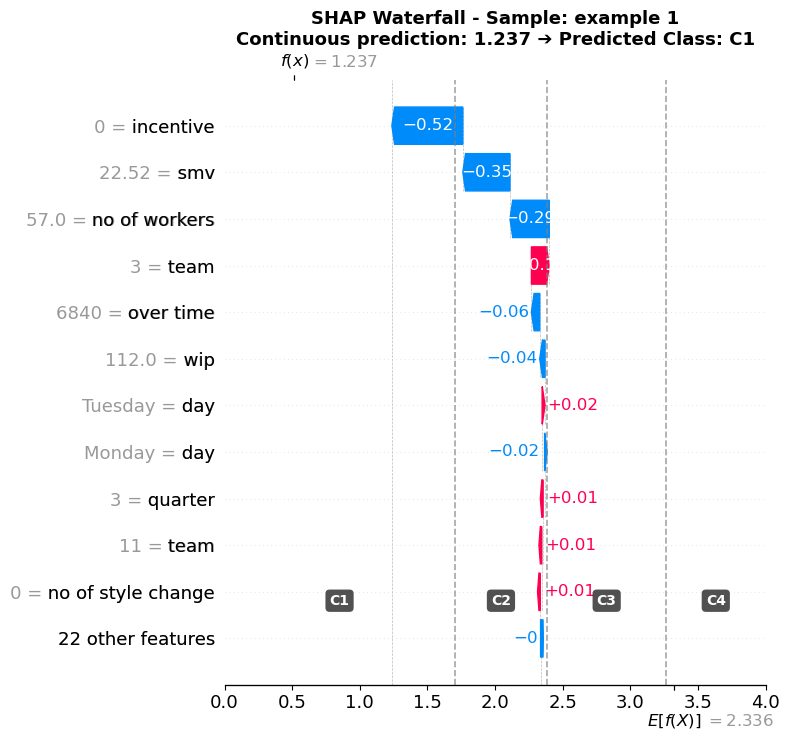

In [66]:
data = {
    'quarter' : ['Quarter1'],
    'department': ['sweing'],
    'day': ['Tuesday'],
    'team': [3],
    'smv': [22.52],
    'wip': [112.0],
    'over_time': [6840],
    'incentive': [0],
    'idle_time': [0.0],
    'idle_men': [0],
    'no_of_style_change': [0],
    'no_of_workers': [57.0]
}

categorical_cols = [
    'department'
]

# Define numerical columns
numeric_cols = ['targeted_productivity',
                'smv', 'wip', 'over_time', 
                'incentive', 'idle_time', 'idle_men',
                'no_of_workers']


# Creamos el DataFrame
df_sample = pd.DataFrame(data)

plot_waterfall(
    df_sample, 
    preprocessor, 
    final_model, 
    explainer, 
    best_thresholds, 
    'example 1'
)

#plot_waterfall(df_sample,preprocessor, final_model, explainer,'"example 1"')

We can see that the incentive is very strong for obtaining class 0 and for not obtaining classes 1 and 2. Therefore, we could try to improve the productivity incrementing incentive. Let's consider an incentive of 50 and keep the rest of the variables:

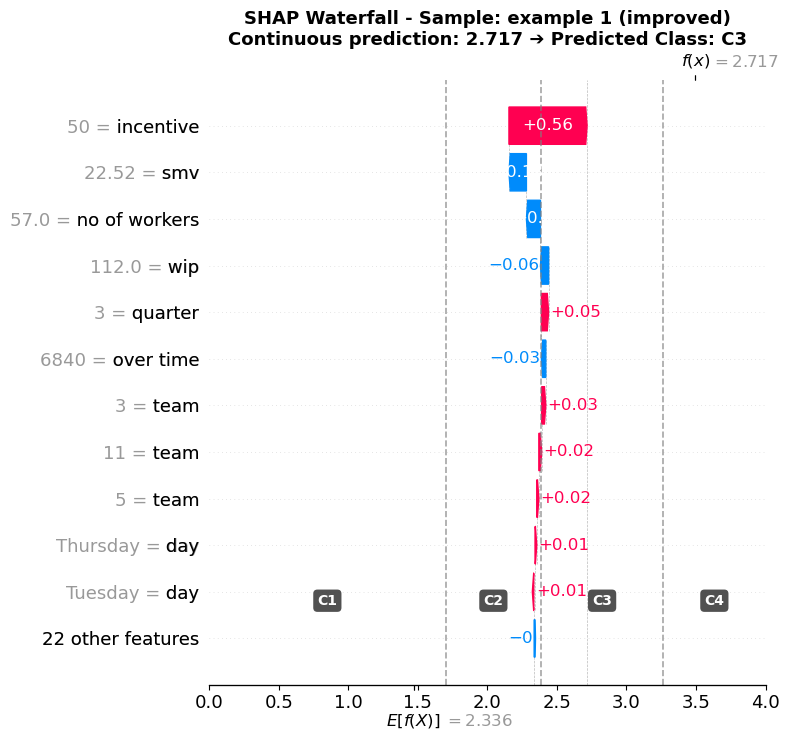

In [67]:
data = {
    'quarter' : ['Quarter1'],
    'department': ['sweing'],
    'day': ['Tuesday'],
    'team': [3],
    'smv': [22.52],
    'wip': [112.0],
    'over_time': [6840],
    'incentive': [50],
    'idle_time': [0.0],
    'idle_men': [0],
    'no_of_style_change': [0],
    'no_of_workers': [57.0]
}

# Creamos el DataFrame
df_sample = pd.DataFrame(data)

plot_waterfall(
    df_sample, 
    preprocessor, 
    final_model, 
    explainer, 
    best_thresholds, 
    'example 1 (improved)'
)

Running this What-If analysis demonstrates how the model functions as a dynamic decision-support tool. In our test scenario, adjusting a key operational input allowed the predicted output to shift from Class 1 (Low Productivity) to Class 3 (High Productivity).

It is important to note that this result is not a guaranteed deterministic output, but rather an empirical sensitivity test. It demonstrates that, based on historical patterns, changing this specific variable significantly shifts the likelihood of achieving higher throughput. 

### Industrial implications summary

The integration of our predictive model into plant operations offers four major strategic advantages over traditional goal-setting methods:<br>
- Correction of Systematic Target Overestimation: Traditional target setting (Targeted) creates severe operational noise by over-promising intermediate output (Classes 2 and 3) while completely neglecting Class 4 capabilities. Our model realigns expectations with historical capacity, preventing supply chain bottlenecks and bottlenecking downstream logistics.<br>
- Drastic Reduction of Large Planning Errors: The error distribution demonstrates that our model achieves zero absolute error in almost 150 instances, sharply decaying for errors of 1, 2, or 3 classes. In contrast, target productivity generates significantly higher frequencies of 1-class and 2-class misalignments, leading to costly over- or under-staffing. <br>
- Measurable Lift in Planning Accuracy: Transitioning from traditional human targeting to our predictive model generates a 35.14% lift in overall accuracy (rising from 46.25% to 62.50%). This substantial increase reduces operational uncertainty across all production shifts.<br>
- Data-Driven What-If Simulations: Plant managers can use the trained pipeline as a decision-support tool. By tweaking actionable inputs (such as adjusting financial incentive structures or reallocating no of workers and over_time), management can simulate productivity outcomes before committing operational budget.